# DQN тест на торговой среде

Простой запуск обучения DQN на `MyTradingEnv` и базовый анализ результатов.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
sys.path.append(str(project_root / 'src'))

from env.trading_env import MyTradingEnv
from agents.train_dqn import train_dqn, DQNConfig


In [2]:
df_train = pd.read_csv('../data/raw/binance_BTCUSDT_1h_2020.csv')
df_test = pd.read_csv('../data/raw/binance_BTCUSDT_1h_2021.csv')

df_train.head()


,open,high,low,close,volume
0,7195.24,7196.25,7175.46,7177.02,511.814901
1,7176.47,7230.00,7175.71,7216.27,883.052603
2,7215.52,7244.87,7211.41,7242.85,655.156809
3,7242.66,7245.00,7220.00,7225.01,783.724867
4,7225.00,7230.00,7215.03,7217.27,467.812578


In [ ]:
env_train = MyTradingEnv(df_train, window_size=10, max_steps=500)
env_train.clear_history()
config = DQNConfig(total_timesteps=250_000)
result = train_dqn(env_train, config)
result['model']


Using cuda device
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.81     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1487     |
|    time_elapsed     | 1        |
|    total_timesteps  | 2000     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.0977   |
|    n_updates        | 249      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.62     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1262     |
|    time_elapsed     | 3        |
|    total_timesteps  | 4000     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.0755   |
|    n_updates        | 749      |
----------------------------------
----------------------------------
| rollout/            |          |
| 

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

train_steps = env_train.get_steps_df()
train_steps.head()


,episode,step,df_index,action,reward,terminated,truncated,portfolio_value,cash,position,units,entry_price,position_value,holding_time,current_price,n_trades,last_exit_reason,unrealized_pnl
0,1,1,7280,0,0.000000,False,False,1000.000000,1.000000e+03,0,0.00000,0.000000,0.000000,0,13625.92,0,NaN,0.000000
1,1,2,7281,2,0.000000,False,False,1000.000000,1.000000e+03,0,0.00000,0.000000,0.000000,0,13547.45,0,NaN,0.000000
2,1,3,7282,1,-0.059970,False,False,999.400300,1.364187e-13,1,0.07374,13559.866545,999.400300,0,13553.09,0,NaN,-0.499700
3,1,4,7283,1,0.051723,False,False,999.917215,1.364187e-13,1,0.07374,13559.866545,999.917215,1,13560.10,0,NaN,0.017215
4,1,5,7284,1,0.405307,False,False,1003.969947,1.364187e-13,1,0.07374,13559.866545,1003.969947,2,13615.06,0,NaN,4.069947


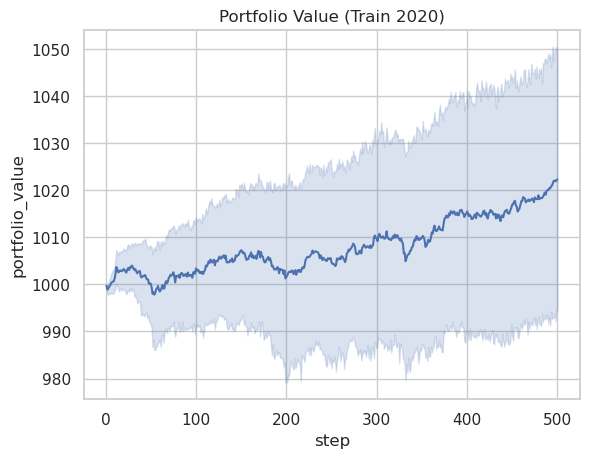

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

sns.lineplot(data=train_steps, x='step', y='portfolio_value')
plt.title('Portfolio Value (Train 2020)')
plt.show()


In [8]:
model = result['model']
env_test = MyTradingEnv(df_test, window_size=10)
env_test.clear_history()
obs, _ = env_test.reset()
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_test.step(int(action))
    done = terminated or truncated

test_steps = env_test.get_steps_df()
test_trades = env_test.get_trades_df()
test_steps.head()


,episode,step,df_index,action,reward,terminated,truncated,portfolio_value,cash,position,units,entry_price,position_value,holding_time,current_price,n_trades,last_exit_reason,unrealized_pnl
0,1,1,5153,2,0.0,False,False,1000.0,1000.0,0,0.0,0.0,0.0,0,38406.75,0,NaN,0.0
1,1,2,5154,2,0.0,False,False,1000.0,1000.0,0,0.0,0.0,0.0,0,38355.99,0,NaN,0.0
2,1,3,5155,2,0.0,False,False,1000.0,1000.0,0,0.0,0.0,0.0,0,38095.66,0,NaN,0.0
3,1,4,5156,2,0.0,False,False,1000.0,1000.0,0,0.0,0.0,0.0,0,37976.81,0,NaN,0.0
4,1,5,5157,2,0.0,False,False,1000.0,1000.0,0,0.0,0.0,0.0,0,37970.66,0,NaN,0.0


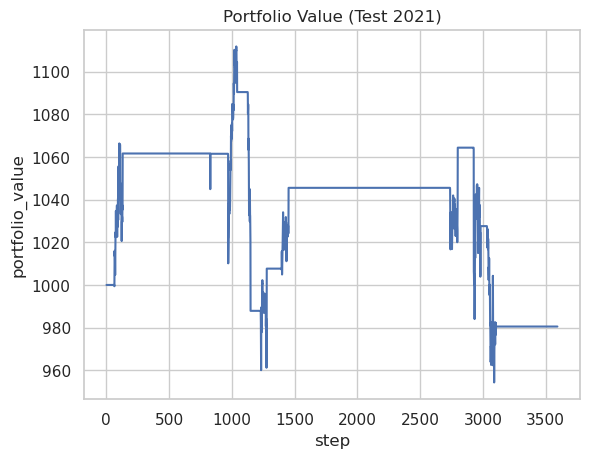

,entry_price,exit_price,pnl,units,holding_time,max_drawdown,exit_reason
0,42221.079990,44832.682445,61.743055,0.023682,66,0.000000,agent
1,47397.787050,47401.287500,-0.027764,0.022396,2,0.015649,agent
2,46163.080005,47430.822725,29.039474,0.022992,72,0.048302,time
3,45961.339185,41645.856655,-102.474289,0.023723,22,0.093440,drawdown
4,42371.985405,43229.704335,19.894057,0.023312,48,0.028066,agent


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

sns.lineplot(data=test_steps, x='step', y='portfolio_value')
plt.title('Portfolio Value (Test 2021)')
plt.show()

trades_df = test_trades
trades_df.head()
